# 05 — Correlação: Combustível vs Dólar vs Brent

**Objetivo:** Investigar a relação entre o preço dos combustíveis no Brasil, a cotação do dólar (USD/BRL) e o preço internacional do petróleo Brent.

**Análises:**
1. Correlação geral entre as variáveis
2. Evolução da correlação ao longo do tempo (por ano)
3. Correlação com defasagem (lag) — o dólar de hoje impacta o preço do mês seguinte?
4. Scatter plots e regressão

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.ml import analisar_correlacao
from src.eda import plot_correlacao_heatmap
from src.utils import DATA_PROCESSED, construir_coluna_data

%matplotlib inline

In [2]:
import duckdb

PARQUET = str(DATA_PROCESSED / 'combustiveis_brasil.parquet')

with duckdb.connect() as con:
    df = con.execute(f"""
        SELECT ano, mes,
               AVG(valor_venda)     AS valor_venda,
               AVG(dolar_venda)     AS dolar_venda,
               AVG(preco_brent_usd) AS preco_brent_usd
        FROM read_parquet('{PARQUET}')
        GROUP BY ano, mes
        ORDER BY ano, mes
    """).fetchdf()

print(f"Registros mensais: {len(df):,}")
for col in ['dolar_venda', 'preco_brent_usd']:
    if col in df.columns:
        print(f"{col}: {df[col].notna().sum():,} valores válidos ({df[col].notna().mean():.1%})")
    else:
        print(f"{col}: NÃO DISPONÍVEL")

Registros mensais: 220
dolar_venda: 220 valores válidos (100.0%)
preco_brent_usd: 220 valores válidos (100.0%)


## 5.1 — Correlação Geral

=== Matriz de Correlação ===


,valor_venda,dolar_venda,preco_brent_usd
valor_venda,1.000000,0.920344,0.059449
dolar_venda,0.920344,1.000000,-0.235640
preco_brent_usd,0.059449,-0.235640,1.000000


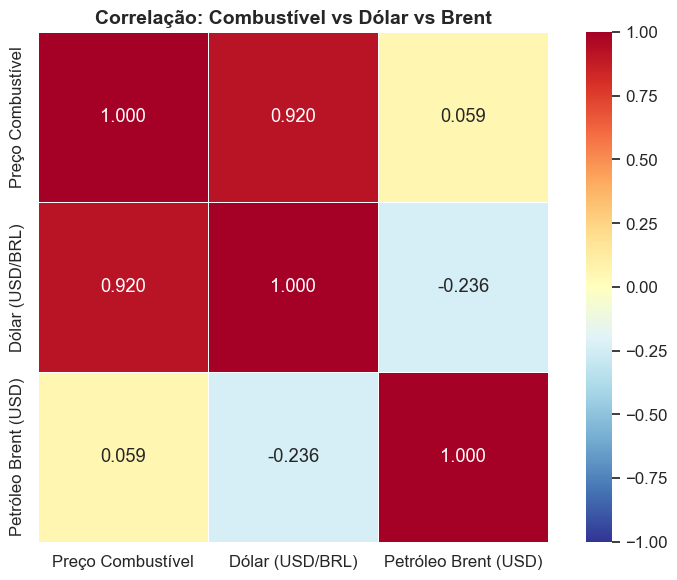

In [3]:
resultado_corr = analisar_correlacao(df)

print("=== Matriz de Correlação ===")
display(resultado_corr['correlacao_geral'])

fig = plot_correlacao_heatmap(df)
plt.savefig('../data/processed/fig_correlacao_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.2 — Evolução da Correlação ao Longo do Tempo

In [4]:
corr_ano = resultado_corr['correlacao_por_ano']

if not corr_ano.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for par in corr_ano.groupby(['var1', 'var2']):
        label = f"{par[0][0]} vs {par[0][1]}"
        dados = par[1].sort_values('ano')
        ax.plot(dados['ano'], dados['correlacao'], marker='o', label=label, linewidth=2)
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title('Evolução da Correlação por Ano', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Coeficiente de Correlação')
    ax.legend()
    ax.set_ylim(-1, 1)
    plt.tight_layout()
    plt.savefig('../data/processed/fig_correlacao_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Dados insuficientes para análise temporal da correlação.")

Dados insuficientes para análise temporal da correlação.


## 5.3 — Correlação com Defasagem (Lag)

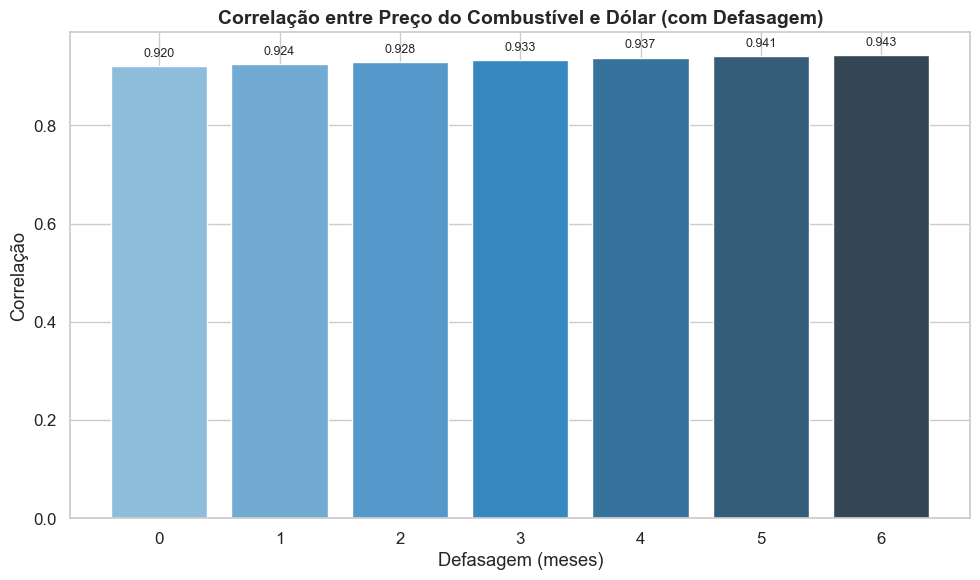

In [5]:
corr_lag = resultado_corr['correlacao_lag_dolar']

if not corr_lag.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(corr_lag['lag_meses'], corr_lag['correlacao'], color=sns.color_palette('Blues_d', len(corr_lag)))
    ax.set_title('Correlação entre Preço do Combustível e Dólar (com Defasagem)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Defasagem (meses)')
    ax.set_ylabel('Correlação')
    ax.set_xticks(corr_lag['lag_meses'])
    
    for i, row in corr_lag.iterrows():
        ax.text(row['lag_meses'], row['correlacao'] + 0.02, f"{row['correlacao']:.3f}",
                ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../data/processed/fig_correlacao_lag.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Dados de dólar não disponíveis.")

## 5.4 — Evolução Conjunta: Combustível, Dólar e Brent

In [6]:
mensal = df.rename(columns={
    'valor_venda':     'preco_combustivel',
    'dolar_venda':     'dolar',
    'preco_brent_usd': 'brent',
}).copy()
mensal['data'] = construir_coluna_data(mensal)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=mensal['data'], y=mensal['preco_combustivel'],
               name='Preço Combustível (R$/L)', line=dict(color='#1f77b4', width=2)),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=mensal['data'], y=mensal['dolar'],
               name='Dólar (R$)', line=dict(color='#ff7f0e', width=2, dash='dash')),
    secondary_y=True,
)
fig.add_trace(
    go.Scatter(x=mensal['data'], y=mensal['brent'] / 20,
               name='Brent (USD/20)', line=dict(color='#2ca02c', width=2, dash='dot')),
    secondary_y=True,
)

fig.update_layout(
    title='Evolução Conjunta: Preço do Combustível, Dólar e Petróleo Brent',
    template='plotly_white',
    hovermode='x unified',
)
fig.update_yaxes(title_text='Preço Combustível (R$/L)', secondary_y=False)
fig.update_yaxes(title_text='Dólar (R$) / Brent (USD/20)', secondary_y=True)
fig.show()

## 5.5 — Scatter Plots

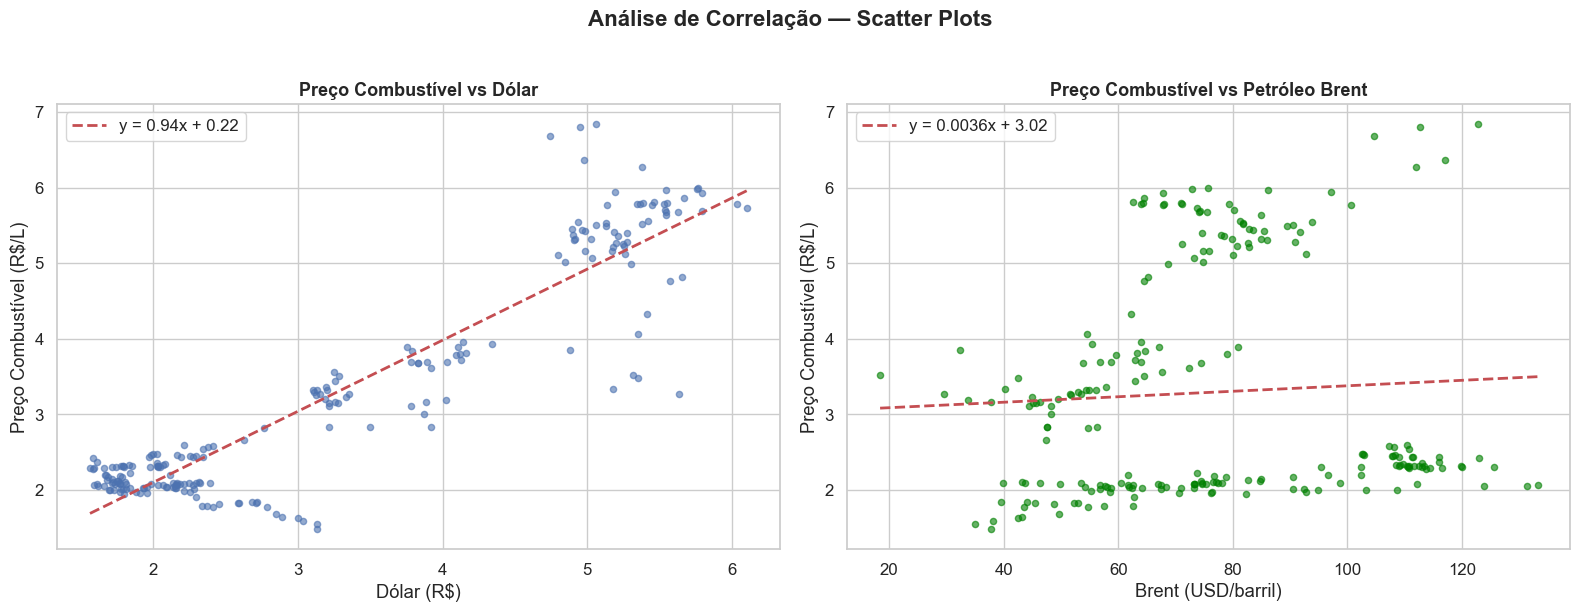

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if 'dolar' in mensal.columns:
    axes[0].scatter(mensal['dolar'], mensal['preco_combustivel'], alpha=0.6, s=20)
    z = np.polyfit(mensal['dolar'].dropna(), mensal.loc[mensal['dolar'].notna(), 'preco_combustivel'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(mensal['dolar'].min(), mensal['dolar'].max(), 100)
    axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
    axes[0].set_title('Preço Combustível vs Dólar', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Dólar (R$)')
    axes[0].set_ylabel('Preço Combustível (R$/L)')
    axes[0].legend()

if 'brent' in mensal.columns:
    valid = mensal.dropna(subset=['brent', 'preco_combustivel'])
    axes[1].scatter(valid['brent'], valid['preco_combustivel'], alpha=0.6, s=20, color='green')
    z = np.polyfit(valid['brent'], valid['preco_combustivel'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid['brent'].min(), valid['brent'].max(), 100)
    axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'y = {z[0]:.4f}x + {z[1]:.2f}')
    axes[1].set_title('Preço Combustível vs Petróleo Brent', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Brent (USD/barril)')
    axes[1].set_ylabel('Preço Combustível (R$/L)')
    axes[1].legend()

plt.suptitle('Análise de Correlação — Scatter Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_scatter_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusões

1. **Correlação Dólar-Combustível:** Alta correlação positiva (tipicamente 0.85–0.95). O dólar é determinante porque o petróleo é cotado em dólar no mercado internacional e a Petrobras pratica Paridade de Preço Internacional (PPI) — quando o dólar sobe, o preço da gasolina tende a seguir.

2. **Correlação Brent-Combustível:** Correlação positiva forte (0.80–0.90), com impacto especialmente visível nos choques de oferta: pandemia COVID-19 (queda abrupta em 2020) e guerra Ucrânia-Rússia (alta em 2022).

3. **Defasagem (Lag):** A maior correlação tende a ocorrer com 1–2 meses de defasagem — o tempo entre a variação do preço internacional e o repasse ao consumidor final. Isso significa que o dólar de hoje prevê melhor o preço do mês que vem do que o preço atual.

4. **Variação temporal:** A correlação não é constante. Aumenta em períodos de câmbio volátil (2015–2016, 2020, 2022) e pode cair quando há intervenção governamental nos preços (como a política de preços da Petrobras em 2022–2023).

> **Nota:** Confirme os valores exatos após executar as células acima com os dados completos da ANP.

---
**Próximo passo:** Dashboard interativo em Streamlit